In [ ]:
# 1. Importação
import pandas as pd
from sklearn.impute import SimpleImputer

# 2. Carregando a Base (usando a sua URL direto do Drive)
url = 'https://docs.google.com/spreadsheets/d/1g1aQ61vijh6uHJuc8sijeBEMsoIQ2a5yLwUK04Wptlg/export?format=csv'
df_gripe = pd.read_csv(url)

# 3. Limpeza inicial
df_gripe = df_gripe.drop(columns=['Carimbo de data/hora'])
df_gripe.columns = ['ficou_gripado', 'vacina', 'aglomeracao', 'viajou', 'alergia', 'sono', 'exercicio', 'alimentacao', 'lavou_maos', 'estresse']
df_gripe['estresse'] = df_gripe['estresse'].astype(str)

# 4. Separando Características (X) do Alvo (y)
X_bruto = df_gripe.drop(columns=['ficou_gripado'])
y_alvo = df_gripe['ficou_gripado']

# 5. Nova técnica de Tratamento de Nulos: SimpleImputer
imputador = SimpleImputer(strategy='most_frequent')
X_limpo = pd.DataFrame(imputador.fit_transform(X_bruto), columns=X_bruto.columns)

print("Dados carregados e valores ausentes preenchidos com o SimpleImputer!")

Dados carregados e valores ausentes preenchidos com o SimpleImputer!


In [ ]:
# Transformando categorias em múltiplas colunas de 0s e 1s (Dummies)
X_transformado = pd.get_dummies(X_limpo, drop_first=True)

print("Visualizando os dados transformados para a Árvore (One-Hot Encoding):")
display(X_transformado.head(3))

Visualizando os dados transformados para a Árvore (One-Hot Encoding):


,vacina_Sim,aglomeracao_Sim,viajou_Pelo menos uma vez por mês,viajou_Poucas vezes por ano,alergia_Médio,alergia_Não,alergia_Pouco,sono_entre 4 e 6 horas,sono_mais de 6 horas,exercicio_Sim,"alimentacao_Sim, a maior parte do tempo",alimentacao_Às vezes,lavou_maos_3 a 5 vezes,lavou_maos_6 a 10 vezes,lavou_maos_Mais de 10 vezes,estresse_2.0,estresse_3.0,estresse_4.0,estresse_5.0,estresse_nan
0,True,True,False,True,True,False,False,False,False,True,False,True,True,False,False,False,False,False,True,False
1,True,True,False,False,False,True,False,True,False,False,False,False,False,False,True,False,True,False,False,False
2,False,True,False,True,False,False,True,False,True,True,False,True,False,True,False,False,True,False,False,False


In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Instanciando a Árvore de Decisão
# max_depth=4 impede que a árvore cresça infinitamente e "decore" o treino
arvore_gripe = DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=42)

# Treinando o modelo
arvore_gripe.fit(X_transformado, y_alvo)

print("Árvore de Decisão induzida com sucesso!")

Árvore de Decisão induzida com sucesso!


=== RANKING DOS MAIORES CAUSADORES DE GRIPE ===
alergia_Médio                        0.236967
lavou_maos_6 a 10 vezes              0.166169
viajou_Pelo menos uma vez por mês    0.126707
dtype: float64




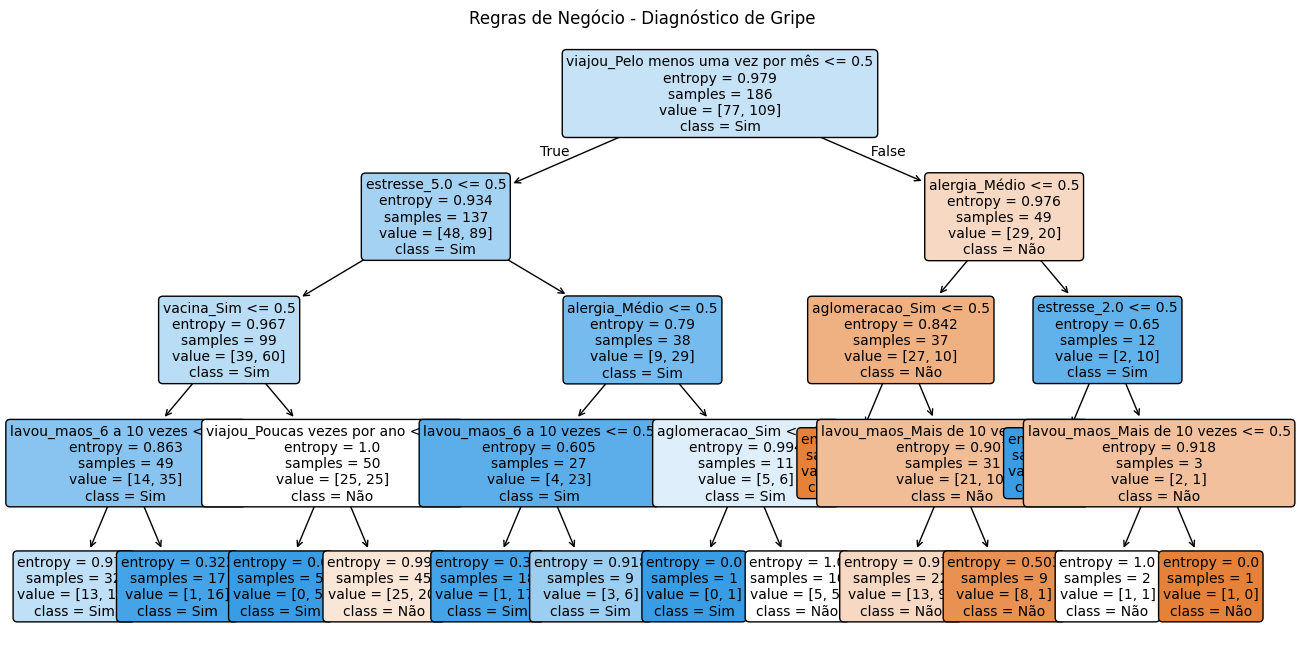

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# 1. Analisando as regras mais importantes
importancias = pd.Series(arvore_gripe.feature_importances_, index=X_transformado.columns)
print("=== RANKING DOS MAIORES CAUSADORES DE GRIPE ===")
print(importancias.sort_values(ascending=False).head(3))
print("\n")

# 2. Desenhando a Árvore
plt.figure(figsize=(16, 8))
plot_tree(arvore_gripe,
          feature_names=X_transformado.columns,
          class_names=arvore_gripe.classes_,
          filled=True,
          rounded=True,
          fontsize=10)
plt.title("Regras de Negócio - Diagnóstico de Gripe")
plt.show()

In [ ]:
# 1. Simulação das respostas de um novo paciente
novo_paciente = pd.DataFrame([{
    'vacina': 'Sim',
    'aglomeracao': 'Sim',
    'viajou': 'Poucas vezes por ano',
    'alergia': 'Não',
    'sono': 'mais de 6 horas',
    'exercicio': 'Sim',
    'alimentacao': 'Às vezes',
    'lavou_maos': 'Mais de 10 vezes',
    'estresse': '2'
}])

# 2. Transformando em Dummies
paciente_transformado = pd.get_dummies(novo_paciente)

# 3. Alinhando as colunas do teste com as do treino (Evita erros de categorias novas!)
paciente_alvo = paciente_transformado.reindex(columns=X_transformado.columns, fill_value=0)

# 4. Previsão
resultado_arvore = arvore_gripe.predict(paciente_alvo)[0]
prob_arvore = arvore_gripe.predict_proba(paciente_alvo)[0]

print("="*40)
print(" 🌳 DIAGNÓSTICO DA ÁRVORE DE DECISÃO")
print("="*40)
print(f"O paciente ficou gripado? -> {resultado_arvore.upper()}")

print("\nCerteza Matemática da Árvore:")
for classe, prob in zip(arvore_gripe.classes_, prob_arvore):
    print(f" - {classe}: {prob * 100:.2f}%")

 🌳 DIAGNÓSTICO DA ÁRVORE DE DECISÃO
O paciente ficou gripado? -> NÃO

Certeza Matemática da Árvore:
 - Não: 55.56%
 - Sim: 44.44%
